# Dataset508 Results Preview -- SmallRefinementENet on the "hard" curriculum

Evaluates `nnUNetTrainerSmallRefinementENet` trained on
`Dataset508_ARCADE_refinement_hard` (see
`dataset-prep/prepare_arcade_508_refinement_hard.py`) against its held-out
test split.

**Why this notebook is structured the way it is**: Dataset507's version of
this net showed a big pooled-dice jump that turned out ambiguous -- 75% of
that dataset was patches where the input predicted-mask channel was already
correct, so a network could win mostly by copying it through. Dataset508
removes that shortcut entirely (50% real discontinuity / 25%
synthetically-corrupted / 25% empty -- no unbroken "normal" category at
all), and training now uses a gap-focused loss
(`nnUNetTrainerSmallRefinementENet._gap_pixel_weight`) that upweights BCE on
exactly the pixels where the input disagrees with GT.

There's no separately-trained single-channel baseline for Dataset508 yet, so
instead of baseline-vs-refinement (507's approach), this notebook compares
the trained net against a **trivial passthrough floor**: channel 1 (the
input predicted probability) thresholded at 0.5, with no network involved
at all. That's a sharper test of "is it just copying" than a second
trained model would be -- it's *literally* the copy-through strategy. Two
numbers matter most:

- **Per-category dice**, refinement vs. passthrough -- especially the
  `discont` row (real ENetOriginal failures, not synthetic corruption).
- **Gap-recovery rate**: of the pixels where passthrough disagrees with GT
  (its errors, by definition), what fraction does the refinement net
  correctly fix? Passthrough's gap-recovery rate is 0% by construction --
  this number is the most direct measurement of whether the net does
  anything beyond copying.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from PIL import Image

# Same numpy/torch checkpoint-loading fix as analysis/507_ARCADE_refinement/
# preview_507_results.ipynb: checkpoints trained under numpy>=2.0 fail to
# load under numpy 1.26.4's torch.load(..., weights_only=False) with
# "TypeError: scalar() argument 1 must be numpy.dtype, not
# numpy.dtypes.Float64DType". Patch numpy.core.multiarray.scalar to coerce
# the 2.x dtype-class instance back to a real np.dtype first.
import numpy.core.multiarray as _ma

_orig_scalar = _ma.scalar


def _patched_scalar(dtype, obj):
    if not isinstance(dtype, np.dtype):
        try:
            dtype = np.dtype(dtype.type) if hasattr(dtype, "type") else np.dtype(dtype)
        except Exception as e:
            raise TypeError(f"could not coerce {dtype!r} to np.dtype") from e
    return _orig_scalar(dtype, obj)


_ma.scalar = _patched_scalar


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "lightm-unet").exists() and (candidate / "data").exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
PACKAGE_ROOT = REPO_ROOT / "lightm-unet"
sys.path.insert(0, str(PACKAGE_ROOT))
from nnunetv2.nets.SmallRefinementENet import SmallRefinementENet  # noqa: E402

DATASET_NAME = "Dataset508_ARCADE_refinement_hard"
PLANS_NAME = "nnUNetPlans"
CONFIGURATION = "2d"
FOLD = 0
CHECKPOINT_NAME = "checkpoint_best.pth"

DATASET_DIR = REPO_ROOT / "data" / "nnUNet_raw" / DATASET_NAME
IMAGES_TS_DIR = DATASET_DIR / "imagesTs"
LABELS_TS_DIR = DATASET_DIR / "labelsTs"
NNUNET_RESULTS = REPO_ROOT / "data" / "nnUNET_results"

TRAINER = "nnUNetTrainerSmallRefinementENet"
CHECKPOINT = NNUNET_RESULTS / DATASET_NAME / f"{TRAINER}__{PLANS_NAME}__{CONFIGURATION}" / f"fold_{FOLD}" / CHECKPOINT_NAME

METRICS_DIR = REPO_ROOT / "analysis" / "508_ARCADE_refinement_hard" / "results"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Must match nnUNetTrainerSmallRefinementENet.py defaults used at training time.
STEM_CHANNELS = 8
STAGE_CHANNELS = 32
THRESHOLD = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repo root   :", REPO_ROOT)
print("Dataset dir :", DATASET_DIR)
print("Checkpoint  :", CHECKPOINT, CHECKPOINT.exists())
print("Device      :", DEVICE)

Repo root   : /workspace/LightM-UNet
Dataset dir : /workspace/LightM-UNet/data/nnUNet_raw/Dataset508_ARCADE_refinement_hard
Checkpoint  : /workspace/LightM-UNet/data/nnUNET_results/Dataset508_ARCADE_refinement_hard/nnUNetTrainerSmallRefinementENet__nnUNetPlans__2d/fold_0/checkpoint_best.pth True
Device      : cuda


## Load the trained model

In [2]:
def load_checkpoint_into(model: torch.nn.Module, path: Path) -> dict:
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["network_weights"])
    return checkpoint


refinement_model = SmallRefinementENet(stem_channels=STEM_CHANNELS, stage_channels=STAGE_CHANNELS)
checkpoint = load_checkpoint_into(refinement_model, CHECKPOINT)
refinement_model = refinement_model.to(DEVICE).eval()

print(f"Trainer: {TRAINER}")
print(f"Epoch: {checkpoint.get('current_epoch')}")
print(f"Params: {sum(p.numel() for p in refinement_model.parameters()):,}")

Trainer: nnUNetTrainerSmallRefinementENet
Epoch: 113
Params: 31,113


## Sample index -- parse category from case id

Case ids are `{source_stem}_{category}_{idx:03d}` (`category` in `discont` /
`corrupt` / `empty`), per `dataset-prep/prepare_arcade_508_refinement_hard.py`.

In [3]:
def case_id_from_image(path: Path) -> str:
    stem = path.stem
    return stem[:-5] if stem.endswith("_0000") else stem


def category_of(case_id: str) -> str:
    return case_id.rsplit("_", 2)[1]


img_files = sorted(IMAGES_TS_DIR.glob("*_0000.png"))
gt_files = {p.stem: p for p in LABELS_TS_DIR.glob("*.png")}

samples = []
for img in img_files:
    cid = case_id_from_image(img)
    if cid in gt_files:
        samples.append({
            "case_id": cid, "category": category_of(cid),
            "image": img, "pred_prob": IMAGES_TS_DIR / f"{cid}_0001.png", "gt": gt_files[cid],
        })

print(f"Matched test samples: {len(samples)}")
cat_counts = pd.Series([s["category"] for s in samples]).value_counts()
print(cat_counts)

Matched test samples: 8420
discont    4210
corrupt    2105
empty      2105
Name: count, dtype: int64


## Inference helpers

No padding dance needed here, unlike the Dataset507 notebook -- Dataset508's
patches are natively 96x96 (confirmed in the training plan: `patch_size:
[96, 96]`, and the preprocessed .npy patches themselves are already 96x96,
not padded up from something smaller like 507's 85x85 was). Channel 1 is
continuous vessel probability (`1 - P(background)`, uint8-quantized), z-score
normalized per-image at both preprocessing and here, matching training.

In [4]:
def load_gray(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)


def load_gt(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr


def zscore_normalize(image: np.ndarray) -> np.ndarray:
    mean = image.mean()
    std = image.std()
    return (image - mean) / max(std, 1e-8)


@torch.no_grad()
def predict_case(idx: int) -> dict:
    item = samples[idx]
    raw = load_gray(item["image"])
    pred_prob_raw = load_gray(item["pred_prob"]) / 255.0  # back to [0, 1] probability
    gt = load_gt(item["gt"]) > 0

    raw_n = zscore_normalize(raw)
    pred_n = zscore_normalize(pred_prob_raw * 255.0)  # normalize on the same 0-255 scale used at train time

    x = torch.stack([torch.from_numpy(raw_n).float(), torch.from_numpy(pred_n).float()], dim=0)[None].to(DEVICE)
    refinement_logits = refinement_model(x)
    refinement_prob = torch.sigmoid(refinement_logits)[0, 0].cpu().numpy()

    passthrough_pred = pred_prob_raw > THRESHOLD  # trivial floor: no network, just the input channel

    return {
        "raw": raw, "pred_prob_input": pred_prob_raw, "gt": gt,
        "passthrough_pred": passthrough_pred, "refinement_prob": refinement_prob,
    }

## Metrics over the full test split, per category

Two things per case: standard dice/precision/recall (passthrough vs.
refinement, against GT), and **gap-recovery rate** -- restricted to exactly
the pixels where passthrough disagrees with GT (its errors), what fraction
does the refinement net get right? This is the number a pure copy-through
strategy cannot get above 0% on, by construction.

In [5]:
EPS = 1e-8


def prf_from_counts(tp: int, fp: int, fn: int, tn: int) -> dict[str, float]:
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    dice = (2 * tp) / (2 * tp + fp + fn + EPS)
    accuracy = (tp + tn) / (tp + fp + fn + tn + EPS)
    return {"dice_f1": dice, "precision": precision, "recall_sensitivity": recall, "accuracy": accuracy}


def counts(gt: np.ndarray, pred: np.ndarray) -> tuple[int, int, int, int]:
    tp = int((gt & pred).sum()); fp = int((~gt & pred).sum())
    fn = int((gt & ~pred).sum()); tn = int((~gt & ~pred).sum())
    return tp, fp, fn, tn


rows = []
for idx, item in enumerate(samples):
    out = predict_case(idx)
    gt = out["gt"]
    passthrough_pred = out["passthrough_pred"]
    refinement_pred = out["refinement_prob"] > THRESHOLD

    row = {"case_id": item["case_id"], "category": item["category"], "gt_vessel_px": int(gt.sum())}
    row.update({f"passthrough_{k}": v for k, v in prf_from_counts(*counts(gt, passthrough_pred)).items()})
    row.update({f"refinement_{k}": v for k, v in prf_from_counts(*counts(gt, refinement_pred)).items()})

    # Gap-recovery rate: of the pixels where passthrough disagrees with GT,
    # what fraction does refinement get right?
    disagreement = passthrough_pred != gt
    n_disagreement = int(disagreement.sum())
    if n_disagreement > 0:
        n_fixed = int((disagreement & (refinement_pred == gt)).sum())
        row["gap_recovery_rate"] = n_fixed / n_disagreement
    else:
        row["gap_recovery_rate"] = np.nan  # passthrough was already perfect on this patch -- nothing to recover
    row["n_disagreement_px"] = n_disagreement

    rows.append(row)

per_image_metrics = pd.DataFrame(rows)
per_image_metrics.to_csv(METRICS_DIR / "per_image_metrics.csv", index=False)

print("Overall (pooled mean across all test patches):")
display(per_image_metrics[["passthrough_dice_f1", "refinement_dice_f1"]].mean().to_frame("mean_dice"))

print("\nPer-category mean dice -- THE KEY RESULT:")
category_summary = (
    per_image_metrics.groupby("category")[["passthrough_dice_f1", "refinement_dice_f1"]]
    .mean()
    .assign(refinement_minus_passthrough=lambda d: d["refinement_dice_f1"] - d["passthrough_dice_f1"])
    .reindex(["discont", "corrupt", "empty"])
)
display(category_summary)

print("\nPer-category mean gap-recovery rate (NaN-safe mean; passthrough-perfect patches excluded) --")
print("passthrough is 0% by construction; this is the real test of whether the net fixes anything:")
gap_recovery_summary = (
    per_image_metrics.groupby("category")["gap_recovery_rate"]
    .agg(["mean", "count"])
    .reindex(["discont", "corrupt", "empty"])
)
display(gap_recovery_summary)

category_summary.to_csv(METRICS_DIR / "category_summary.csv")
gap_recovery_summary.to_csv(METRICS_DIR / "gap_recovery_summary.csv")
print("Saved to", METRICS_DIR)

Overall (pooled mean across all test patches):


,mean_dice
passthrough_dice_f1,0.565051
refinement_dice_f1,0.600984



Per-category mean dice -- THE KEY RESULT:


,passthrough_dice_f1,refinement_dice_f1,refinement_minus_passthrough
category,,,
discont,0.697644,0.736989,0.039344
corrupt,0.843023,0.908097,0.065074
empty,0.021893,0.021862,-0.000031



Per-category mean gap-recovery rate (NaN-safe mean; passthrough-perfect patches excluded) --
passthrough is 0% by construction; this is the real test of whether the net fixes anything:


,mean,count
category,,
discont,0.302137,4210
corrupt,0.652090,2105
empty,0.351525,251


Saved to /workspace/LightM-UNet/analysis/508_ARCADE_refinement_hard/results


## Visual comparison, a few examples per category

Raw / input predicted-probability channel / GT / passthrough (thresholded
input, the trivial floor) / refinement prediction, for a handful of cases
from each category. `discont` is the priority category to look at closely
-- real ENetOriginal failures, not synthetic corruption.

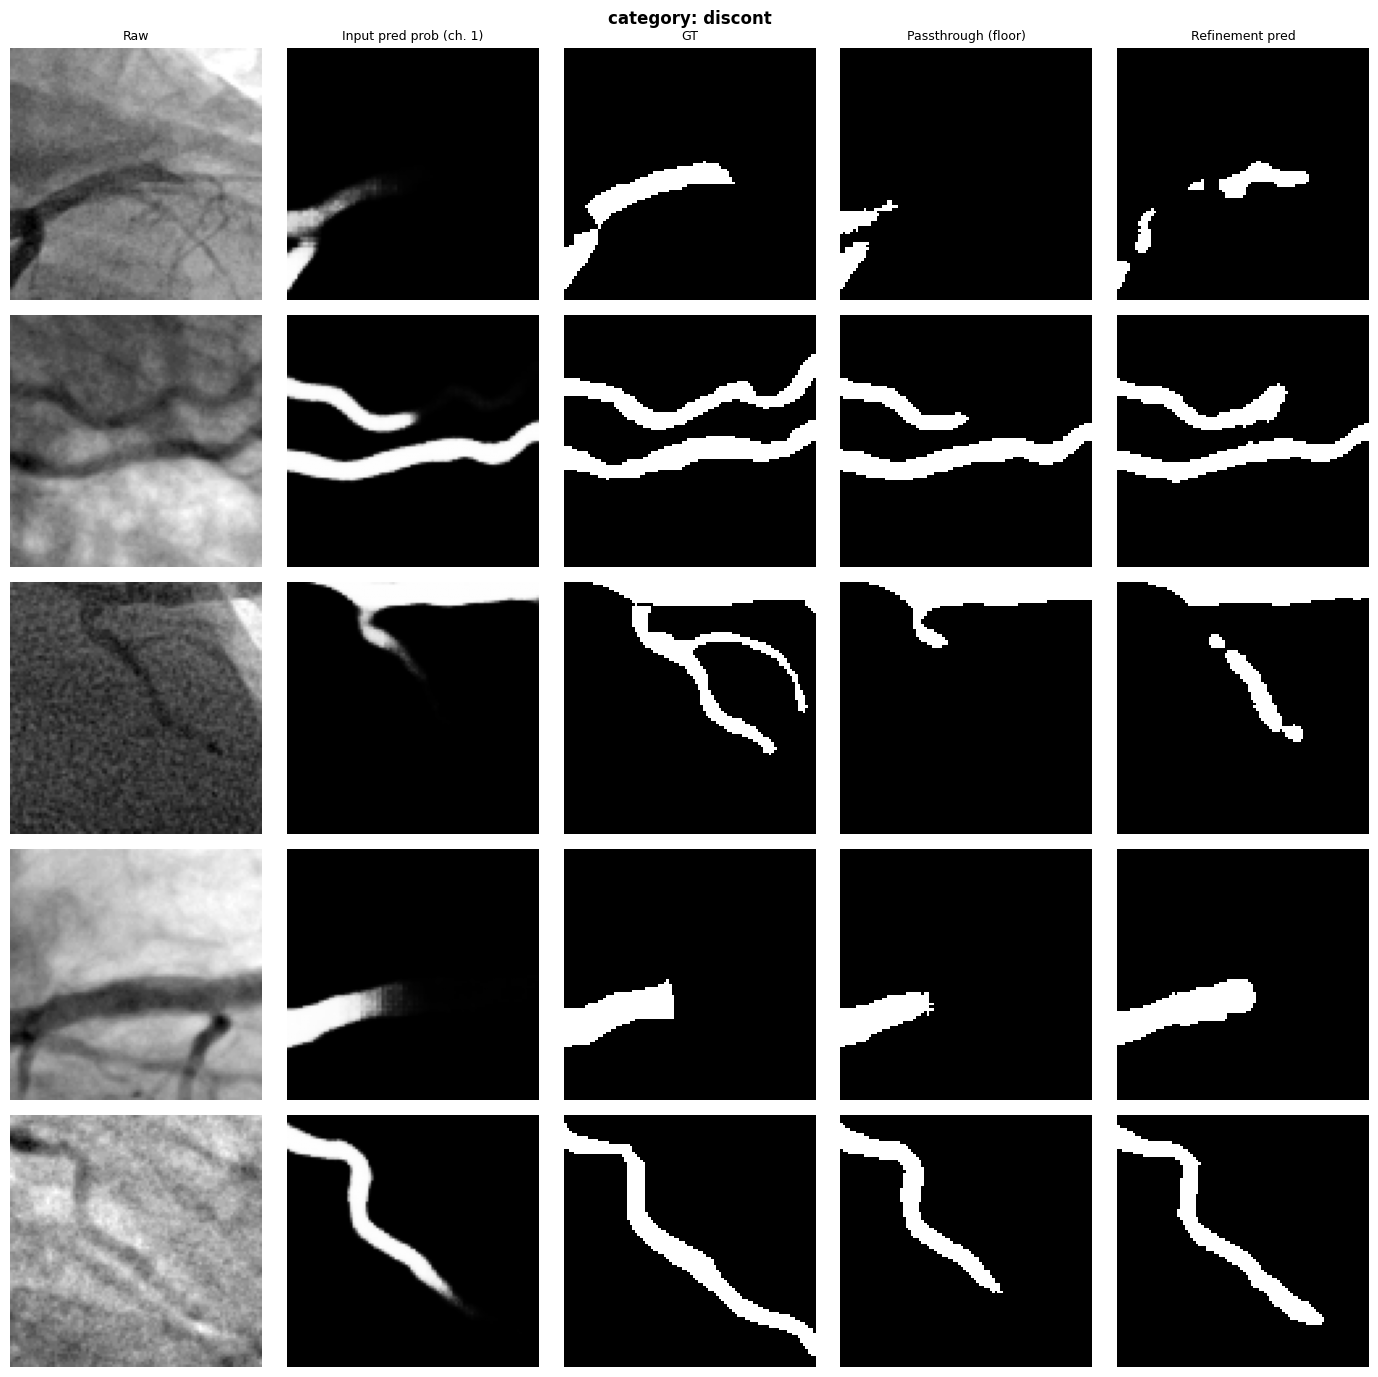

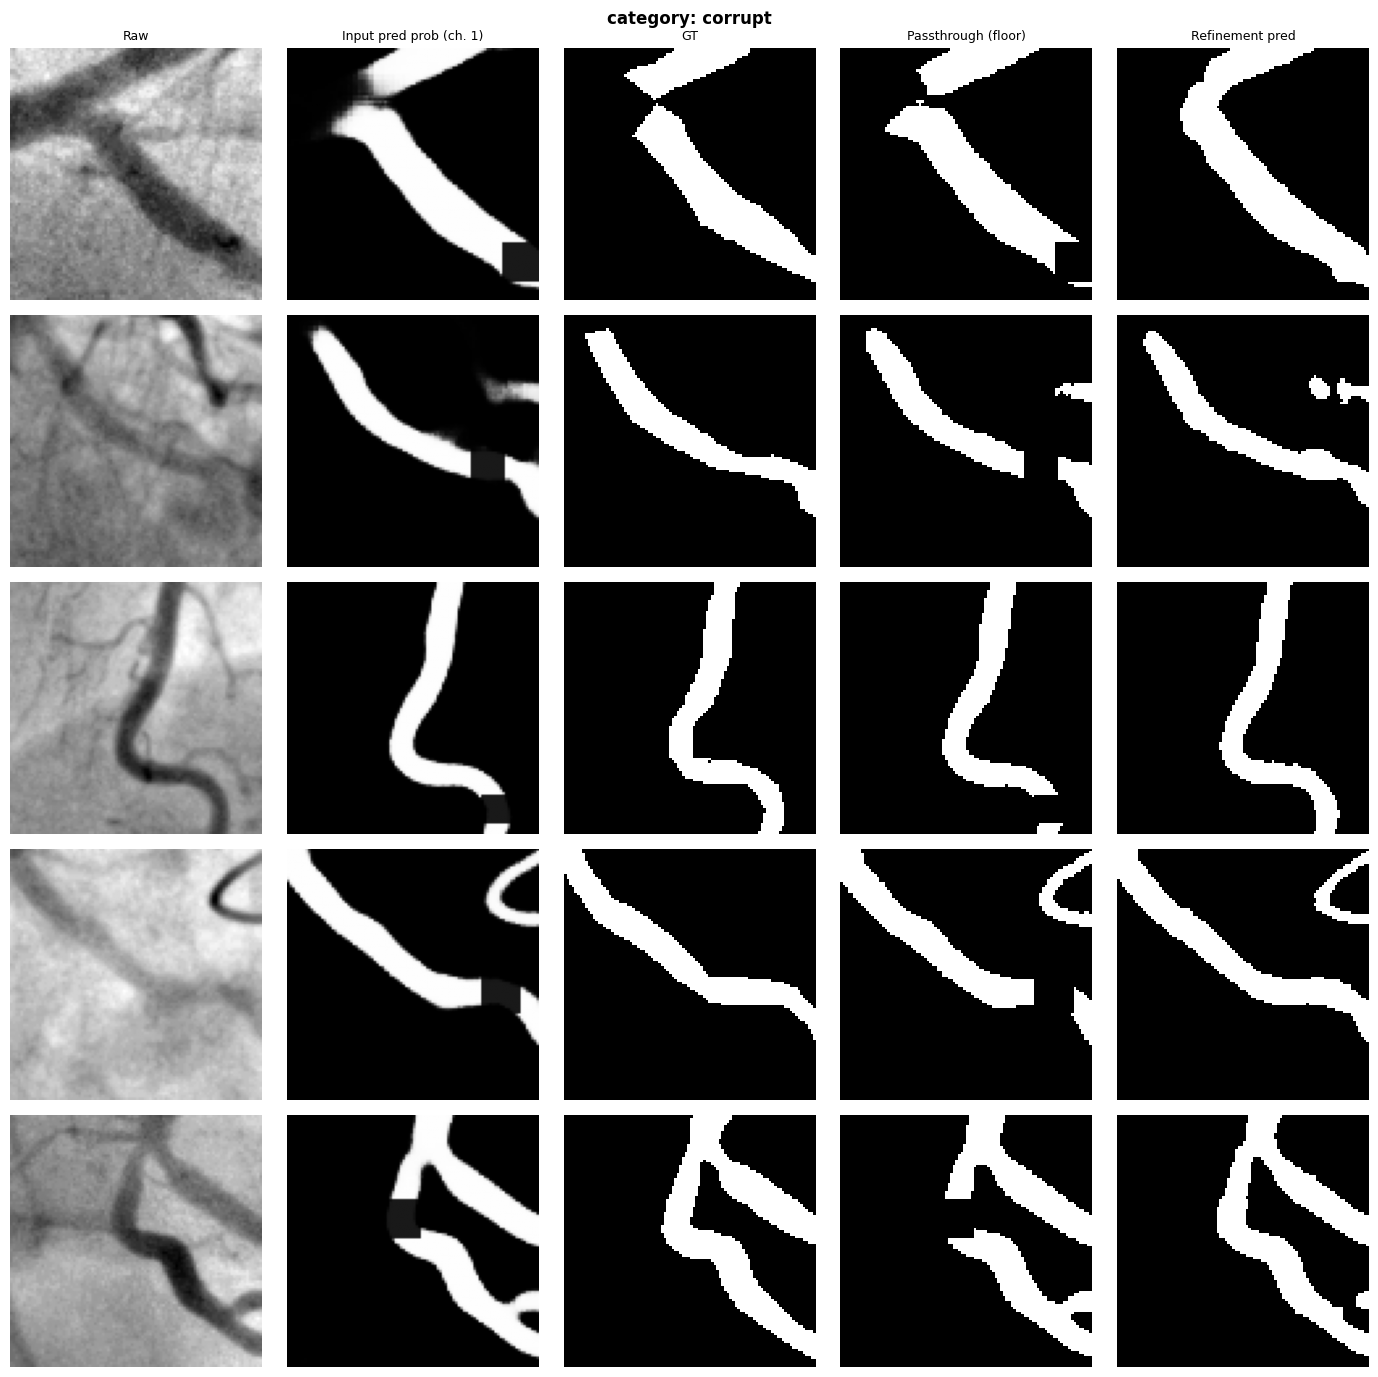

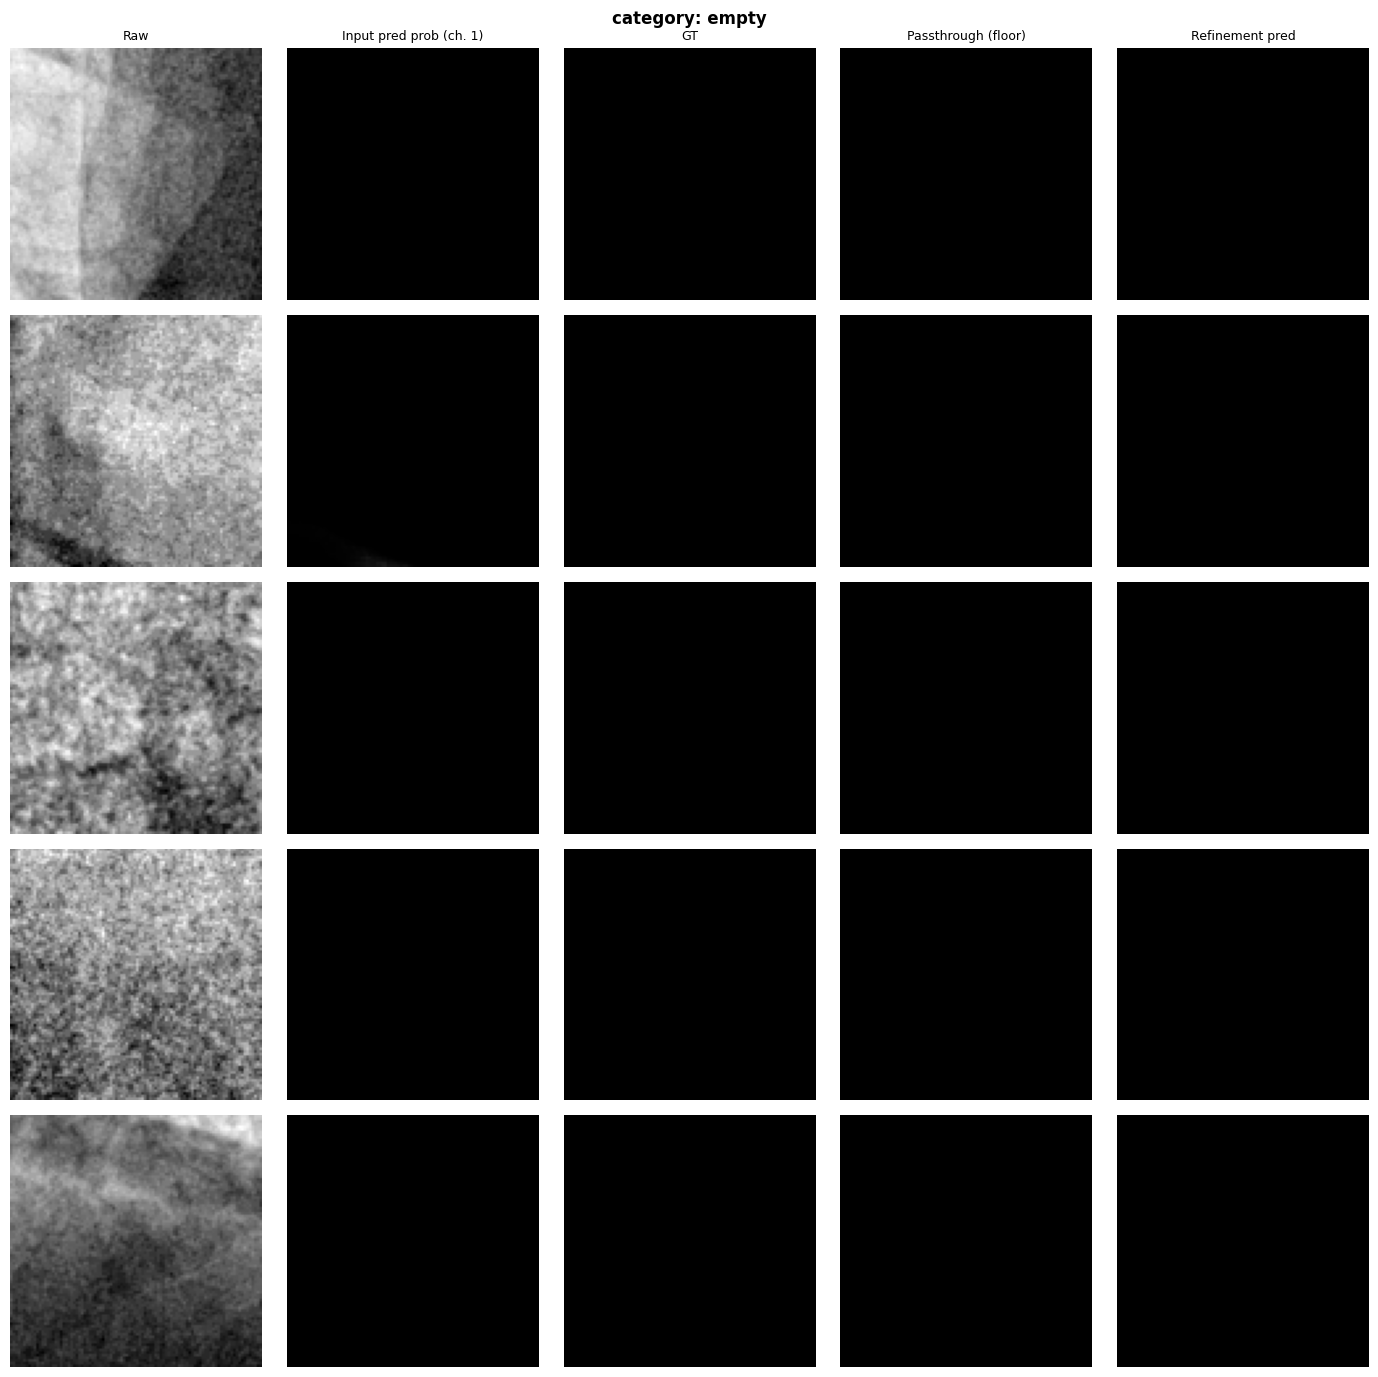

In [ ]:
IMSHOW_MASK_KW = dict(cmap=mcolors.ListedColormap(["#000000", "#ffffff"]), norm=mcolors.BoundaryNorm([0, 1, 2], 2), interpolation="nearest")

rng = np.random.default_rng(0)


def show_category(category: str, n: int = 20):
    indices = [i for i, s in enumerate(samples) if s["category"] == category]
    chosen = rng.choice(indices, size=min(n, len(indices)), replace=False)
    fig, axes = plt.subplots(len(chosen), 5, figsize=(14, 2.8 * len(chosen)))
    axes = np.atleast_2d(axes)
    for col, title in enumerate(["Raw", "Input pred prob (ch. 1)", "GT", "Passthrough (floor)", "Refinement pred"]):
        axes[0, col].set_title(title, fontsize=9)
    for row, idx in enumerate(chosen):
        out = predict_case(idx)
        p_dice = per_image_metrics.loc[idx, "passthrough_dice_f1"]
        r_dice = per_image_metrics.loc[idx, "refinement_dice_f1"]
        gap_rec = per_image_metrics.loc[idx, "gap_recovery_rate"]
        gap_rec_str = f"{gap_rec:.2f}" if not np.isnan(gap_rec) else "n/a"
        axes[row, 0].imshow(out["raw"], cmap="gray")
        axes[row, 0].set_ylabel(
            f"{samples[idx]['case_id']}\np={p_dice:.2f} r={r_dice:.2f}\ngap_rec={gap_rec_str}",
            fontsize=6.5, rotation=0, labelpad=52, va="center",
        )
        axes[row, 0].axis("off")
        axes[row, 1].imshow(out["pred_prob_input"], cmap="gray", vmin=0, vmax=1); axes[row, 1].axis("off")
        axes[row, 2].imshow(out["gt"], **IMSHOW_MASK_KW); axes[row, 2].axis("off")
        axes[row, 3].imshow(out["passthrough_pred"], **IMSHOW_MASK_KW); axes[row, 3].axis("off")
        axes[row, 4].imshow(out["refinement_prob"] > THRESHOLD, **IMSHOW_MASK_KW); axes[row, 4].axis("off")
    fig.suptitle(f"category: {category}", fontweight="bold")
    plt.tight_layout()
    fig.savefig(METRICS_DIR / f"category_{category}_examples.png", dpi=150, bbox_inches="tight")
    plt.show()


for cat in ["discont", "corrupt", "empty"]:
    show_category(cat)

## Conclusion

Fill in after running:

- Does `refinement_minus_passthrough` on the `discont` row hold up (a real,
  positive dice gain on real ENetOriginal failures), or is it near zero?
- Does the `discont` gap-recovery rate show the net actually fixing a
  meaningful fraction of passthrough's errors, or is it near 0% (the
  passthrough floor itself)?
- Does `corrupt` (synthetic breaks) look similar to `discont` (real breaks)
  -- if corrupt recovers well but discont doesn't, the synthetic corruption
  may not be representative of what real failures actually look like.
- Does `empty` stay high for both passthrough and refinement (no FP
  hallucination introduced by the refinement step)?